# Discrete Dynamical Systems

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V09 — "Discrete Dynamical Systems" (DeepLearning.AI).*

One final application, and a beautiful one: **discrete dynamical systems** driven by a **Markov matrix**. Repeatedly applying the matrix drives the system to an **equilibrium** — which turns out to be an **eigenvector with eigenvalue 1**. This is the machinery behind modeling how people navigate the internet (PageRank). We cover:

- **Markov / transition matrices** and **state vectors**.
- **Iterating** the system and watching it **stabilize**.
- The **equilibrium vector** as an eigenvector with eigenvalue $1$ — reached from *any* start.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. The weather as a Markov matrix

Tomorrow's weather depends on today's. The transition probabilities:

| today ↓ / tomorrow → | sunny | cloudy | rainy |
|---|---|---|---|
| **sunny** | 0.80 | 0.15 | 0.05 |
| **cloudy** | 0.45 | 0.35 | 0.20 |
| **rainy** | 0.30 | 0.40 | 0.30 |

We store this as a **transition matrix** $T$ where **each column is one of today's states** (so tomorrow-given-today reads down a column). Every column is **non-negative and sums to 1** — that makes $T$ a **Markov matrix**, which lets us infer how the system evolves.

In [2]:
# columns = today's state (sunny, cloudy, rainy); rows = tomorrow's state
T = np.array([[0.80, 0.45, 0.30],
              [0.15, 0.35, 0.40],
              [0.05, 0.20, 0.30]])
labels = ['sunny', 'cloudy', 'rainy']
print('column sums (must all be 1):', T.sum(axis=0))
print('all entries non-negative :', (T >= 0).all())

column sums (must all be 1): [1. 1. 1.]
all entries non-negative : True


## 2. State vectors and stepping forward

Suppose **today is cloudy**. With 100% certainty the **state vector** is $X_0 = (0, 1, 0)$. Tomorrow's probabilities come from a single matrix-vector product:

$$ X_1 = T X_0 = (0.45,\ 0.35,\ 0.20), $$

which is just the **cloudy column** of $T$. Apply $T$ again for the day after, and so on: $X_{n+1} = T X_n$.

In [3]:
X0 = np.array([0, 1, 0])   # today is cloudy
X1 = T @ X0
X2 = T @ X1
X3 = T @ X2
print('X0 (today)      =', X0)
print('X1 (+1 day)     =', X1)
print('X2 (+2 days)    =', X2)   # (0.5775, 0.2700, 0.1525)
print('X3 (+3 days)    =', X3)

X0 (today)      = [0 1 0]
X1 (+1 day)     = [0.45 0.35 0.2 ]
X2 (+2 days)    = [0.5775 0.27   0.1525]
X3 (+3 days)    = [0.6293 0.2421 0.1286]


## 3. Iterating: the system stabilizes

Keep applying $T$. The change between consecutive states shrinks — first in the first decimal, then the second, then the fourth... By around $X_{10}$ the state barely moves at all: $T X_{10} \approx X_{10}$. The system has reached an **equilibrium**.

In [4]:
states = [X0.astype(float)]
for _ in range(12):
    states.append(T @ states[-1])
states = np.array(states)

for n in [0, 1, 2, 3, 5, 6, 10, 11]:
    print(f'X{n:<2} = {states[n]}')
print()
print('change ||X11 - X10|| =', np.linalg.norm(states[11] - states[10]))

X0  = [0. 1. 0.]
X1  = [0.45 0.35 0.2 ]
X2  = [0.5775 0.27   0.1525]
X3  = [0.6293 0.2421 0.1286]
X5  = [0.6601 0.2257 0.1142]
X6  = [0.6639 0.2237 0.1124]
X10 = [0.6666 0.2223 0.1112]
X11 = [0.6666 0.2222 0.1111]

change ||X11 - X10|| = 6.154400033208807e-05


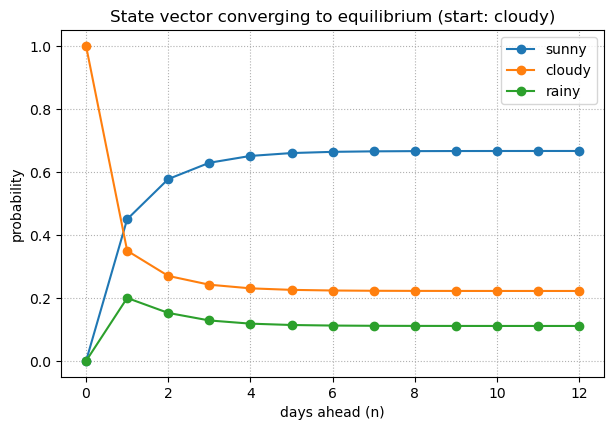

In [5]:
# Plot the probabilities converging to equilibrium
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, lab in enumerate(labels):
    ax.plot(states[:, i], 'o-', label=lab)
ax.set_xlabel('days ahead (n)'); ax.set_ylabel('probability')
ax.grid(True, ls=':'); ax.legend()
ax.set_title('State vector converging to equilibrium (start: cloudy)')
plt.show()

## 4. The equilibrium is an eigenvector (eigenvalue 1)

At equilibrium $T X = X$ — which is exactly the eigenvector equation $T X = \lambda X$ with **$\lambda = 1$**. Once the system reaches this **equilibrium vector**, it can never move away (applying $T$ leaves it unchanged).

$$ \lim_{n\to\infty} X_n = X_{\text{eq}}, \qquad T X_{\text{eq}} = 1 \cdot X_{\text{eq}}. $$

Every Markov (transition) matrix has eigenvalue $1$, so this equilibrium always exists. Its entries are the **long-run probabilities** of sunny / cloudy / rainy on a given day.

In [6]:
# Find the eigenvector of T with eigenvalue 1, normalized to sum to 1
vals, vecs = np.linalg.eig(T)
idx = np.argmin(np.abs(vals - 1))          # the eigenvalue closest to 1
eq = np.real(vecs[:, idx])
eq = eq / eq.sum()                          # make it a probability vector
print('eigenvalue        =', np.real(vals[idx]))
print('equilibrium vector =', eq)
print('iteration limit X12=', states[12])
print('T @ eq             =', T @ eq, ' (unchanged -> eigenvector)')

eigenvalue        = 0.9999999999999996
equilibrium vector = [0.6667 0.2222 0.1111]
iteration limit X12= [0.6667 0.2222 0.1111]
T @ eq             = [0.6667 0.2222 0.1111]  (unchanged -> eigenvector)


## 5. Any starting state reaches the same equilibrium

The remarkable part: **no matter the initial state**, iterating $T$ leads to the **same** equilibrium vector. Starting fully sunny, fully cloudy, or fully rainy — all converge to the same long-run probabilities.

In [7]:
for start, name in [([1, 0, 0], 'sunny'), ([0, 1, 0], 'cloudy'), ([0, 0, 1], 'rainy')]:
    x = np.array(start, dtype=float)
    for _ in range(50):
        x = T @ x
    print(f'start = {name:6s} -> long-run {x}')
print()
print('all match the equilibrium eigenvector:', eq)

start = sunny  -> long-run [0.6667 0.2222 0.1111]
start = cloudy -> long-run [0.6667 0.2222 0.1111]
start = rainy  -> long-run [0.6667 0.2222 0.1111]

all match the equilibrium eigenvector: [0.6667 0.2222 0.1111]


## 6. Why this matters: PageRank and beyond

This is a **straightforward application of eigenvectors**. Model web pages as states and links as transition probabilities: the equilibrium eigenvector gives each page's **long-run visit probability** — the core idea behind **PageRank**. The same discrete-dynamical-system framework appears across the sciences whenever a process steps forward by a fixed transition rule.

*(This closes Week 4. The programming assignment applies these ideas to model traffic between web pages and to run PCA on a dataset of images.)*

## Summary

- A **Markov / transition matrix** has columns that are **non-negative and sum to 1**; a **state vector** holds the current probabilities.
- The system evolves by **repeated matrix-vector products** $X_{n+1} = T X_n$, and it **stabilizes** to an **equilibrium**.
- The equilibrium is an **eigenvector with eigenvalue $1$** ($T X_{\text{eq}} = X_{\text{eq}}$) — every Markov matrix has one, and it gives the **long-run probabilities**.
- The equilibrium is reached from **any** initial state — the basis of applications like **PageRank**.